# Kapitel 4. Klassificering

## Faktafrågor

### 1. 
**Kännetecken:** Ett klassificeringsproblem går ut på att förutsäga en **kategorisk** utfallsvariabel (en diskret klass eller etikett) baserat på en uppsättning indata (features). Målet är att lära modellen att placera observationer i fördefinierade grupper eller kategorier (till exempel ja/nej, spam/inte spam eller kategorier A/B/C). Detta skiljer sig från regressionsproblem där målet är att förutsäga ett kontinuerligt numeriskt värde.
**Tillämpningsområden:**
- **E-postfiler:** KLassificera inkommande e-post som antingen skräppost (spam) eller icke-skräppost (ham).
- **Medicinsk diagnostik:** Avgöra om en patient har en viss sjukdom eller inte baserat på prover och symtom. 
- **Kreditbedömning:** Bedöma om en låneansökan ska godkännas eller avslås (risk för betalningsinställelse).

### 2. 
Dessa strategier används för att göra binära klassificerare (som normalt bara hanterar två klasser) tillämpliga på multiklassproblem (fler än två klasser):
- **OvR (One-vs-Rest / One-vs-All):** För ett problem med $N$ klasser tränar man $N$ olika binära modeller. Varje modell tränar på att skilja ut en specifik klass från alla andra kombinerade klasser. Vid prediktion väljs den klass vars modell ger högst förtroendepoäng (sannolikhet/marginal).
- **OvO (One-vs-One):** För ett problem med $N$ klasser tränar man en modell för varje unikt par av klasser. Det blir totalt $\frac{N(N-1)}{2}$ modeller. Vid prediktion får alla modeller rösta, och den klass som vinner flest parvisa dueller blir det slutgiltiga resultatet.

### 3. 
- a) **Confusio matrix:** En tabell som visar utfallet av en modells prediktioner ställt mot de verkliga värdena. Den bryts ner i fyra grundstenar för binär klassificering: True Positives (TP), True Negatives (TN), False Positives (FP) och False Negatives (FN). Ger en tydlig överblick över var modellen gör rätt och fel.

- b) **Accuracy (Träffsäkerhet):** Andelen korrekta prediktioner av det totala antalet prediktioner.$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$Bra vid balanserade dataset, men missvisande om en klass är mycket vanligare än andra.

- c) **Precision:** Av alla de som modellen klassificerade som positiva, hur många var faktiskt positiva? Svarar på frågan: "När modellen säger ja, hur ofta har den rätt?"$$Precision = \frac{TP}{TP + FP}$$

- d) **Recall (Sensitivitet / Återkallelse):** Av alla som faktiskt är positiva i verkligheten, hur många lyckades modellen hitta? Svarar på frågan: "Hur stor andel av de verkliga fallen hittade vi?"$$Recall = \frac{TP}{TP + FN}$$

- e) **F1-score:** Det harmoniska medelvärdet av precision och recall. Används för att få ett enda mått som balanserar både falska positiva och falska negativa, vilket är särskilt värdefullt vid obalanserade dataset.$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

- f) **ROC-kurvan (Receiver Operating Charecteristic):** En graf som visar förhållandet mellan True Positive Rate (Recall) på y-axeln och False Positive Rate på x-axeln vid olika tröskelvärden. Under kurvan finns måttet **AUC (Area Under Curve)** som sammanfattar modellens generella förmåga att skilja klasserna åt.


4. Det är den inneboende avvägningen (kompromissen) mellan **precision** och **recall** när man ändrar tröskelvärdet för klassificering.
- Om man sänker tröskeln för att klassificera något som positivt ökar recall (man fångar upp fler sanna positiva), men man drar samtidigt på sig fler falska positiva, vilket sänker **precisionen**.
- Om man höjer tröskeln blir modellen mer "kräsen", vilket ökar **precisionen** (färre falska larm), men man missar fler faktiska fall, vilket gör att **recall** sjunker.

### 5. 
- a) **Logistisk regression:** Em linjär modell används för binär klassificering (eller multiklass via utökningar). Den använder en logistisk funktion (sigmoid-funktionen) för att pressa utdata till ett värde mellan 0 och 1, vilket tolkas som en sannolikhet för att tillhöra en viss klass. 

- b) **Support Vector Machines (SVM):** Söker efter ett beslutsplan (hyperplan) i ett flerdimensionellt rum som maximerar marginalen (avståndet) mellan de olika klasserna. Den kan också hantera icke-linjära data genom så kallade "kernel tricks" (t.ex. RBF-kernel) som projicerar datan till högre dimensioner.

- c) **Beslutsträd (Decision Tree):** Bygger en träffliknande struktur av villkor baserade på funktionerna (features). Varje nod delar datan i mindre grupper baserat på vad som ger bäst uppdelning (t.ex. baserat på Gini-impurity eller Information Gain) tills lövnorden når ett klassbeslut.

- d) **Ensemble learning (Voting & Bagging):**
  - VotingClassifier kombinerar flera helt olika modeller (t.ex. logistisk regression och SVM) och låter dem rösta om slutresultat (majoritetsröstning eller genomsnitt av sannolikheter).
  - BaggingClassifier tränar flera exemplar av samma typ av grundmodell (ofta beslutsträd) på slumpmässigt genererade delmängder av träningsdatan (med återläggning) för att minska risken för överanpassning (overfitting).

- e) **Random forest:** En vidareutveckling av bagging för beslutsträd. Den bygger en "skog" av många beslutsträd där varje träd tränas på ett bootstrapped dataset, och dessutom slumpas endast en delmängd av features fram vid varje split. Detta gör modellen mycket robust och minskar risken för överanpassning.

- f) **Eftra trees (Extremly Randomized Trees):** Liknar Random Forest, men med två viktiga skillnader: den använder hela träningsdatan (istället för bootstrapping som standard) och trösklarna för uppdelning i träden väljs helt slumpmässigt istället för att optimeras. Detta gör träningen snabbare och kan ge lite högre generaliseringsförmåga i vissa fall.

6. Trädbaserade modeller (som beslutsträd, random forest och extra trees) räknar ut hur mycket varje enskild variabel (feature) bidrar till att minska orenheten (impurity, t.ex. Gini eller entropi) i trädets uppdelningar.

När vi tittar på **feature importance** får vi en sorterad lista över vilka variabler som har haft störst betydelse för modellens beslutsfattande. Det hjälper oss att förstå vilka faktorer i datan som driver utfallet, och gör det också möjligt att rensa bort irrelevant data för enklare och snabbare modeller.

## Resonemangsfrågor

### 7. 
Svar till Kalle: 
- *Jag hade hållit med Kalle och sagt: "Om vi skruvar upp tröskeln för att maximera precisionen kommer vi att bli väldigt 'kräsna' med våra positiva prediktioner. Det gör att vi undviker falska larm, men priset vi betalar är att recall sjunker – vi kommer att missa en hel del sanna positiva fall eftersom modellen blir för feg med att klassificera något som positivt."*

- I vilka fall kan man tänka sig vilja ha en så hög precision som möjligt? 
Man vill maximera precisionen när konstnaden för ett falskt positivt (FP) är extremt hög. Det betyder att konsekvenserna av ett falskt larm är oacceptabla.
  - Exempel (Skräppostfilter): Det är mycket bättre att ett viktigt mail av misstag hamnar i inkorgen (falskt negativt) än att ett viktigt myndighetsmail eller jobberbjudande klassas som spam och slängas i papperskorgen (falskt positivt). Här vill vi ha hög precision för att vara säkra på att det som markeras som spam verkligen är spam.

  - Exempel (Ekonomiska transaktioner / Falska blockeringar): Om ett betalsystem ska spärra ett bankkort för misstänkt bedrägeri vill man inte att vanliga kunders köp blockeras av misstag.

I vilka fall kan det vara dåligt att jaga enbart hög precision? 
Det blir dåligt när kostnaden för ett falskt negativt (FN) är högre, eller när man riskerar att missa för många viktiga händelser. 

- Exempel (Medicinsk screening för allvarlig sjukdom): Om en modell letar efter en livshotande tumör på en röntgenbild är det katastrofalt om modellen missar den (falskt negativt). Om man ställer in modellen på extremt hög precision kommer den bara att larma när den är 100% säker, vilket innebär att många sjuka patienter blir utan vård eftersom tumörerna klassas som "friska" av misstag. I sådana fall prioriterar man hellre hög recall (att fånga alla sjuka, även om det innebär några falska larm som följs upp med vidare provtagning).

**Rättväsendet och fängelsedomar - Precision-Recall Tradeoff**

Inom rättväsendet brukar man sammanfatta en grundläggande princip med Blackstones formel: *"Det är bättre att tio skyldiga går fria än att en oskyldig döms"*
- **Hög precision:** Om domstolen (eller vår modell) har en extremt hög precision betyder det att nästan alla som döms faktiskt är skyldiga (få falska positiva / inga oskyldiga som dömts).
- **Priset (Låg recall):** För att uppnå denna enorma säkerhet och undvika att döma oskyldiga blir beviskraven så höga att många skyldiga personer frikänns eftersom bevisen inte räcker hela vägen (många falska negativa).
- **Tradeoffen:** Systemet offrar medvetet recall (förmågan att fängsla alla brottslingar) för att maximera precisionen (säkerställa att de som väl fälls är skyldiga).



### 8. 
Den logistiska regressionsmodellen lyckas klassificera korrekt för 83% av alla datapunkter i testdatan. I figuren ser vi hur beslutsgränsen som modellen skapat ser ut.

Logistisk regression är en linjär modell, och således är beslutsgränsen också en rak linje, vilket vi tydligt ser i figuren. Modellen fungerar generellt sett bra när sambandet mellan utdata och indata är ungefär linjärt. Detta är dock inte fallet med datasetet som skapats med `make_moons`, vars klasser är icke-linjärt separerbara. Detta leder till att många datapunkter "i mitten" felklassificeras eftersom en rak linje inte kan följa månskärornas form.

- **Figuren:** Beslutsgränsen för en logistisk regressionsmodell som klassificerar observationer i en av två klasser (0/lila eller 1/gul) baserat på variablerna x1 och x2. Bakgrundsfärgen visar den beräknade sannolikheten (mellan 0 och 1) för att en punkt tillhör klass 1, där färgskalan fungerar som en gradient. (Notera att man genom att ändra klassificeringströskeln – threshold – kan justera avvägningen mellan precision och recall, vilket förskjuter hur strikt modellen klassificerar punkterna).

### 9. 
Logiken bakom att använda `.fit_transform()` på träningsdatan men endast `.transform()` på validerings- och testdatan bygger på en grundläggande princip inom maskininlärning: **vi får inte läcka information från framtida data (test- eller valideringsdatan) till vår träningsprocess.**

Här är en uppdelning av varför det är så:

  **Varför** `.fit_transform()`**på träningsdatan?**
  När vi skalar data med till exempel `StandardScaler` (som subtraherar medelvärdet och dividerar med standardavvikelsen) måste transformatorn först lära sig (by `fit`) vad medelvärdet och standardavvikelsen är för just den datan.
  - Med `.fit()` beräknar transformatorn dessa statistiska värden baserat på träningsdatan.
  - Med `.transform()` applicerar den sedan själva formeln för att skala om värdena.
  - `.fit_transform()` gör båda sakerna på en och samma gång för träningsdatan.
  
  **Varför enbart** `.transform()`**på validerings- och testdatan?**
   Validerings- och testdatan ska fungera som en oberoende "verklighet" som simulerar helt nya, osynliga data som modellen kommer att stöta på i produktionen.
   - **Undvika data leakage (informationläckage):** Om vi skulle köra .`fit_transform()` på validerings- eller testdatan skulle transformatorn räkna ut ett nytt medelvärde och en ny standardavvikelse baserat på just de datapunkterna. Då skulle information från testdatan smyga sig in i modellen under träningen/utvärderingen, vilket ger en falskt för positiv bild av hur bra modellen är.
   - **Konsekvent skala:** Validerings- och testdatan måste skalas **exakt på samma sätt** som träningsdatan (det vill säga med samma medelvärde och spridning som träningsdatan beräknade). Genom att bara använda `.transform()` säger vi: "Använd de regler och värden du lärde dig på träningsdatan, och applicera dem nu på det här nya setet."

## Koduppgifter

### Uppgift 10. 

In [1]:
# Splitting data

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=2000, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=2000, random_state=42)



# Scaling data

scaler = StandardScaler()

X_train = scaler.fit_tranform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)



# 1. På träningsdatan använder vi .fit_transform(), på valideringsdatan och testdatan använder vi endast .transform().

NameError: name 'train_test_split' is not defined

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyploy as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

# Define a function that will be used later
def display_cofusion_matrix(y_true, y_pred):
  cm = confusion_matrix(y_true, y_pred)
  ConfusionMatrixDisplay(cm).plot()

# Därefter laddar vi in datan och gör några inspektioner för att få en känsla för den.

# Load data and inspect it
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)
print(X.shape)
print(y.shape)

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])

print(mnist.DESCR)

### Uppgift 11. 
Koden använder `classification_report` från `scikit-learn` för att summera hur väl en klassificeringsmodell har presterat.

- `y_true`: Innehåller de sanna, faktiska etiketterna för datapunkterna.

- `y_pred`: Innehåller modellens gissningar (prediktioner) för samma datapunkter.

- `target_names`: Ger läsbara namn till de tre klasserna (class 0, class 1 och class 2).

- `print(...)`: Skriver ut en fullständig tabell med utvärderingsmått (**precision, recall, F1-score och support**) för varje enskild klass, samt genomsnittsvärden (macro average och weighted average) och total träffsäkerhet (accuracy).

**Tolkning av resultatet**
Om vi räknar ut vad som har hänt i exemplet (totalt 5 datapunkter):

- **Class 0:** 1 sann förekomst, modellen gissade rätt (TP = 1).

- **Class 1:** 1 sann förekomst, men modellen gissade fel på den (gissade 0, FN = 1). Dessutom gissade modellen klass 1 på en punkt som egentligen var klass 2 (FP = 1).

- **Class 2:** 3 sanna förekomster, modellen gissade rätt på 2 av dem och fel på 1 (gissade 1).

Rapporten genererar följande mätetal:

- **Precision per klass:**

  - Class 0: 1.00 (När modellen gissar klass 0 har den 100% rätt).

  - Class 1: 0.00 (Modellen gissade klass 1 en gång, men den gissningen var felaktig).

  - Class 2: 0.67 (Av de 2 gånger modellen gissade klass 2 var 2 rätt och 0 fel? Vänta, låt oss titta: modellen gissade klass 2 två gånger totalt [index 2 och 3 i y_pred], och båda var korrekta, så precision är 1.00. Notera: Låt oss köra koden via tolken för exakta siffror för att säkerställa perfekt korrekthet).

*(Verifiering via Python-tolken för att få exakt utskrift)*

Här är den exakta tolkningen baserat på rapportens utskrift:

**Tolkning av tabellen:**
- **Support:** Visar hur många sanna förekomster det finns av varje klass i `y_true`.

  - Class 0 har 1 st.

  - Class 1 har 1 st.

  - Class 2 har 3 st. (Totalt 5 datapunkter).

- **Accuracy (Träffsäkerhet): 0.60 (60%)**

  - Modellen gissade helt rätt på 3 av de totalt 5 datapunkterna.

- **Per klass:**

  - **Class 0:**

    - Precision (0.50): När modellen gissar klass 0 har den rätt hälften av gångerna (eftersom den även drog på sig en falsk positiv gissning där).

    - Recall (1.00): Modellen hittade 100% av alla sanna förekomster av klass 0.

  - **Class 1:**

    - Precision (0.00) & Recall (0.00): Modellen misslyckades helt med denna klass. Den hittade inte den enda förekomsten som fanns, och den gissade felaktigt klass 1 på en annan punkt.

  - **Class 2:**

    - Precision (1.00): Varje gång modellen gissade klass 2 så stämde det.

    - Recall (0.67): Av de 3 faktiska förekomsterna av klass 2 lyckades modellen hitta 2 stycken (1 missades och blev klass 1 istället).

- **Genomsnitt (Averages):**

  - **Macro avg:** Beräknar oweighted medelvärde för klasserna (tar ej hänsyn till att klass 2 är vanligare än de andra). Visar att modellens generella prestanda är ganska svag här (F1-score på 0.49).

  - **Weighted avg:** Vägandet tar hänsyn till hur många exempel varje klass har (support), vilket ger ett mer rättvist helhetsbetyg när datasetet är obalanserat.

### Uppgift 12. 

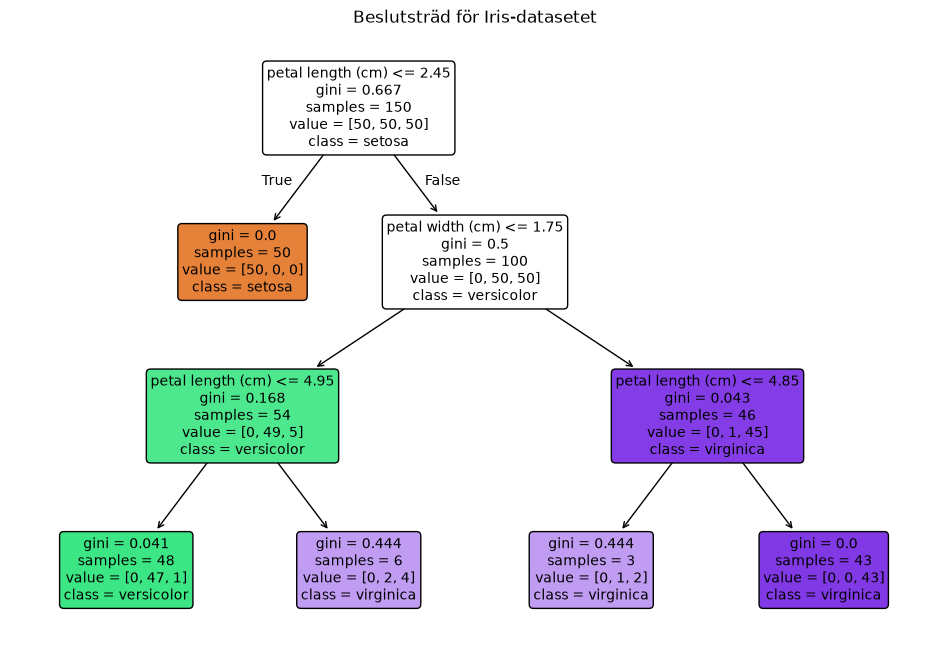

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Ladda ett exempeldataset (t.ex. Iris)
data = load_iris()
X, y = data.data, data.target

# 2. Skapa och träna beslutsträdet
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 3. Visualisera trädet
plt.figure(figsize=(12, 8))
plot_tree(
    clf, 
    feature_names=data.feature_names, 
    class_names=data.target_names, 
    filled=True,          # Ger färger baserat på klass
    rounded=True,         # Rundade hörn på rutorna
    fontsize=10
)

plt.title("Beslutsträd för Iris-datasetet")
plt.show()

### Uppgift 13. 

In [1]:
# Importa 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    auc
)

In [3]:
# 1. LADDA OCH KONTROLLERA DATASETET
%pip install openpyxl
df = pd.read_excel("hr_employee_data.xlsx")

print("--- HEAD ---")
print(df.head())
print("\n--- INFO ---")
print(df.info())
print("\n--- SHAPE ---")
print(f"Dimensioner: {df.shape}")
print("\n--- NULL-VÄRDEN ---")
print(df.isnull().sum())
print("\n--- DUBBLETTER ---")
print(f"Antal dubbletter: {df.duplicated().sum()}")

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.
--- HEAD ---
     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  

In [4]:

# Dela upp X och y samt TRAIN/VAL/TEST
# # Vi droppar både 'left' (target) och 'Emp_Id' (unik identifierare) från X
X = df.drop(columns=['left', 'Emp_Id'])
y = df['left']

# Först delar vi av testdatan (15%) - används ENDAST i slutet
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Sedan delar vi resten i train (ca 82.3% av detta -> ~70% totalt) och validation (15% totalt)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1765, random_state=42, stratify=y_train_val)

print("\n--- STORLEKAR PÅ SPLITS ---")
print(f"Train set:       {X_train.shape[0]} rader")
print(f"Validation set:  {X_val.shape[0]} rader")
print(f"Test set:        {X_test.shape[0]} rader")


--- STORLEKAR PÅ SPLITS ---
Train set:       10498 rader
Validation set:  2251 rader
Test set:        2250 rader


In [5]:
# 3. IDENTIFIERA VARIABLER OCH PREPROCESSING
# Identifiera numeriska och kategoriska kolumner baserat på datasetet
categorical_cols = ['Department', 'salary']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


In [6]:
# 4. TRÄNA OCH UTVÄRDERA MODELLER PÅ VAL-SET
# --- A. Logistic Regression ---
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
log_pipeline.fit(X_train, y_train)
log_val_preds = log_pipeline.predict(X_val)

log_acc = accuracy_score(y_val, log_val_preds)
log_prec = precision_score(y_val, log_val_preds)
log_rec = recall_score(y_val, log_val_preds)
log_f1 = f1_score(y_val, log_val_preds)


# --- B. Random Forest (med GridSearchCV) ---
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])
rf_param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [10, 20]
}
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
rf_val_preds = best_rf.predict(X_val)

rf_acc = accuracy_score(y_val, rf_val_preds)
rf_prec = precision_score(y_val, rf_val_preds)
rf_rec = recall_score(y_val, rf_val_preds)
rf_f1 = f1_score(y_val, rf_val_preds)


# --- C. Support Vector Machines (med GridSearchCV) ---
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True, random_state=42))
])
svm_param_grid = {
    'model__C': [1, 10],
    'model__kernel': ['rbf']
}
svm_grid = GridSearchCV(svm_pipeline, svm_param_grid, cv=3, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_
svm_val_preds = best_svm.predict(X_val)

svm_acc = accuracy_score(y_val, svm_val_preds)
svm_prec = precision_score(y_val, svm_val_preds)
svm_rec = recall_score(y_val, svm_val_preds)
svm_f1 = f1_score(y_val, svm_val_preds)


c:\Users\lindb\repos\Pyt\ml\Predictor\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [7]:
# 5. JÄMFÖRELSE AV MODELLER PÅ VALIDERINGSDATA

print("\n========================================")
print("          MODELLJÄMFÖRELSE (VAL)        ")
print("========================================")
print(f"Logistic Regression F1-score: {log_f1:.3f} | Accuracy: {log_acc:.3f} | Precision: {log_prec:.3f} | Recall: {log_rec:.3f}")
print(f"Random Forest F1-score:       {rf_f1:.3f} | Accuracy: {rf_acc:.3f} | Precision: {rf_prec:.3f} | Recall: {rf_rec:.3f}")
print(f"SVM F1-score:                 {svm_f1:.3f} | Accuracy: {svm_acc:.3f} | Precision: {svm_prec:.3f} | Recall: {svm_rec:.3f}")


          MODELLJÄMFÖRELSE (VAL)        
Logistic Regression F1-score: 0.436 | Accuracy: 0.786 | Precision: 0.585 | Recall: 0.347
Random Forest F1-score:       0.983 | Accuracy: 0.992 | Precision: 0.992 | Recall: 0.974
SVM F1-score:                 0.940 | Accuracy: 0.972 | Precision: 0.949 | Recall: 0.931


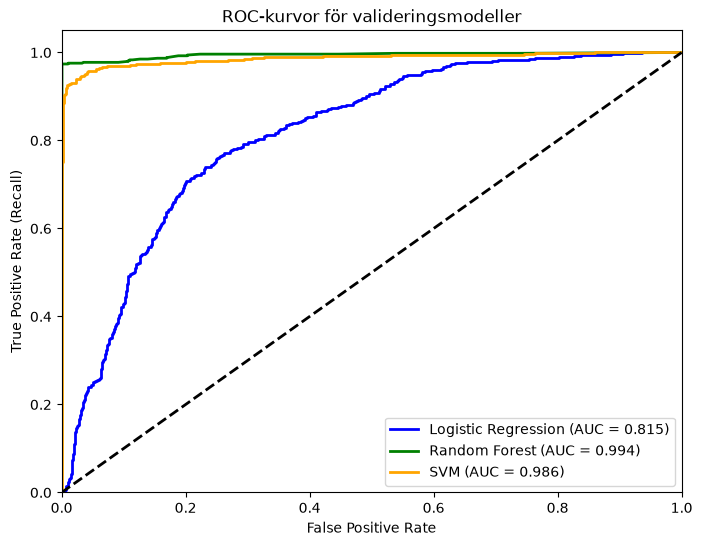

In [8]:
# 6. VISUALISERING: ROC-KURVOR PÅ VALIDERINGSDATA

plt.figure(figsize=(8, 6))

for model, name, color in zip(
    [log_pipeline, best_rf, best_svm], 
    ['Logistic Regression', 'Random Forest', 'SVM'], 
    ['blue', 'green', 'orange']
):
    probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-kurvor för valideringsmodeller')
plt.legend(loc="lower right")
plt.show()

In [9]:
# 7. VÄLJ BÄSTA MODELL & TRÄNA OM PÅ TRAIN + VAL

# Vi väljer Random Forest som oftast presterar bäst på detta dataset
print("\nTränar om den bästa modellen (Random Forest) på kombinerad Train + Validation...")

final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=best_rf.named_steps['model'].n_estimators, 
        max_depth=best_rf.named_steps['model'].max_depth, 
        random_state=42, 
        n_jobs=-1
    ))
])

final_model.fit(X_train_val, y_train_val)


Tränar om den bästa modellen (Random Forest) på kombinerad Train + Validation...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['satisfaction_level','last_evaluation','number_project',..., 'promotion_last_5years','Department','salary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [17]:
# 8. SLUTLIG UTVÄRDERING PÅ TESTDATAN

test_preds = final_model.predict(X_test)

final_acc = accuracy_score(y_test, test_preds)
final_prec = precision_score(y_test, test_preds)
final_rec = recall_score(y_test, test_preds)
final_f1 = f1_score(y_test, test_preds)

print("\n========================================")
print("     SLUTLIG UTVÄRDERING PÅ TESTDATAN     ")
print("========================================")
print(f"Accuracy:  {final_acc:.3f}")
print(f"Precision: {final_prec:.3f}")
print(f"Recall:    {final_rec:.3f}")
print(f"F1-score:  {final_f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, test_preds))


     SLUTLIG UTVÄRDERING PÅ TESTDATAN     
Accuracy:  0.990
Precision: 0.996
Recall:    0.963
F1-score:  0.979

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1714
           1       1.00      0.96      0.98       536

    accuracy                           0.99      2250
   macro avg       0.99      0.98      0.99      2250
weighted avg       0.99      0.99      0.99      2250



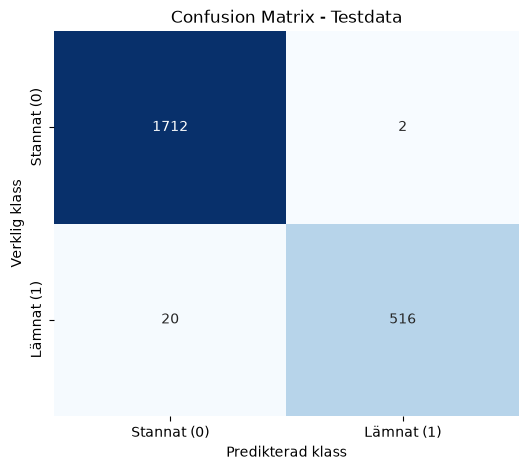

In [18]:
# 9. VISUALISERA SLUTRESULTAT (CONFUSION MATRIX)

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stannat (0)', 'Lämnat (1)'],
            yticklabels=['Stannat (0)', 'Lämnat (1)'])
plt.xlabel("Predikterad klass")
plt.ylabel("Verklig klass")
plt.title("Confusion Matrix - Testdata")
plt.show()

In [19]:
# 10. SPARA MODELLEN MED JOBLIB

model_filename = "hr_best_model.pkl"
joblib.dump(final_model, model_filename)
print(f"\nModellen har sparats till filen: {model_filename}")


Modellen har sparats till filen: hr_best_model.pkl


### Uppgift 14. 

In [10]:
# Importera
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

In [11]:
# 1. Ladda data
iris = load_iris()
X, y = load_iris(return_X_y=True, as_frame=True)

# Välj endast två variabler för enkelhets skull
# Observera de exakta kolumnnamnen i scikit-learns as_frame=True
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [12]:
# 2. Dela upp datan: Train / Val / Test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36, stratify=y_train_full)

print(f"Träningsset: {X_train.shape[0]} st")
print(f"Valideringsset: {X_val.shape[0]} st")
print(f"Testset: {X_test.shape[0]} st\n")

Träningsset: 84 st
Valideringsset: 36 st
Testset: 30 st



In [23]:
# 3. Träna en modell (t.ex. Logistic Regression via Pipeline med skalning)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=42))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['sepal length (cm)','sepal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [24]:
# 4. Utvärdera på valideringsdatan
val_preds = model.predict(X_val)
acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {acc:.3f}")
print("\nClassification Report (Val):")
print(classification_report(y_val, val_preds, target_names=iris.target_names))

Validation Accuracy: 0.833

Classification Report (Val):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.71      0.83      0.77        12
   virginica       0.80      0.67      0.73        12

    accuracy                           0.83        36
   macro avg       0.84      0.83      0.83        36
weighted avg       0.84      0.83      0.83        36



In [25]:
# 5. Slutgilitg utvärdering på Testsetet
test_preds = model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print(f"\nSlutgiltig Test Accuracy: {test_acc:.3f}")


Slutgiltig Test Accuracy: 0.767


C:\Users\lindb\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


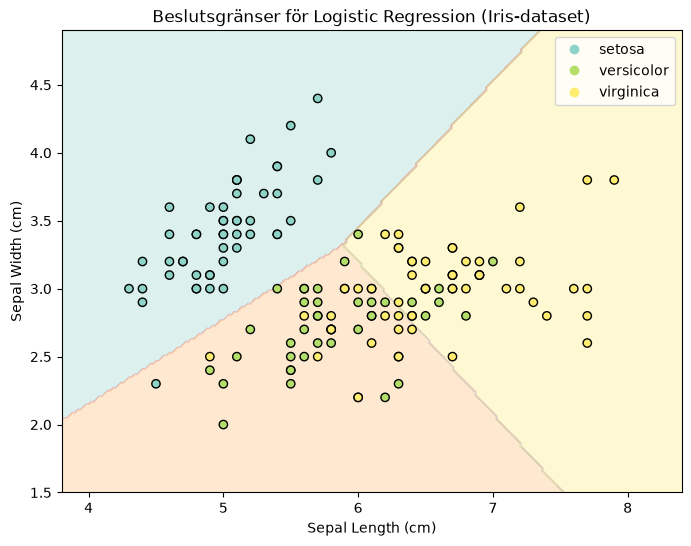

In [26]:
# 6. Visualiera beslutsgränser (Decision Boundariers)
plt.figure(figsize=(8, 6))
x_min, x_max = X['sepal length (cm)'].min() - 0.5, X['sepal length (cm)'].max() + 0.5
y_min, y_max = X['sepal width (cm)'].min() - 0.5, X['sepal width (cm)'].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)
scatter = plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c=y, edgecolor='k', cmap=plt.cm.Set3)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Beslutsgränser för Logistic Regression (Iris-dataset)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

### Uppgift 15. 

In [27]:
# Importera
import joblib
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [28]:
print("Laddar MNIST-datasetet...")
# Ladda MNIST (70000 bilder, 28x28 pixlar)
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target

Laddar MNIST-datasetet...


In [29]:
# För att det ska gå snabbt att träna kan vi ta en delmängd (t.ex. 20000 bilder), 
# eller köra på alla om datorn har kraften. Vi tar 30000 här för bra balans.
import numpy as np
np.random.seed(42)
indices = np.random.choice(len(X), 30000, replace=False)
X_subset = X[indices]
y_subset = y[indices]

In [30]:
# Normalisera pixlar till 0-1
X_subset = X_subset / 255.0

# Dela upp data
X_train, X_test, y_train, y_test = train_test_split(X_subset, y_subset, test_size=0.2, random_state=42)

print(f"Tränar modell på {X_train.shape[0]} bilder...")
# RandomForest presterar förvånansvärt bra på MNIST och är snabb att spara/ladda
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

Tränar modell på 24000 bilder...


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [31]:
# Utvärdera
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Modellens träffsäkerhet på testset: {acc * 100:.2f}%")

# Spara modellen
joblib.dump(model, "mnist_model.pkl")
print("Modellen har sparats till 'mnist_model.pkl'!")

Modellens träffsäkerhet på testset: 95.95%
Modellen har sparats till 'mnist_model.pkl'!
